# Limit Order Book Simulator

**Category:** Microstructure Engines  
**Project ID:** `engines_01_lob_simulator`  

High-performance LOB with price-time priority, Hawkes process arrivals, and multiple order types (limit, market, stop, iceberg)


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.10.19
         torch: 2.7.1+cu118
        device: CUDA (NVIDIA GeForce RTX 4090)
         numpy: 1.26.4
        pandas: 2.3.3
         scipy: 1.15.3
       sklearn: 1.7.2
    matplotlib: 3.10.8


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"hawkes_mu": 50.0}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
                  hawkes_mu: 50.0


## LOB Simulator — Hawkes Process Arrivals + Price-Time Matching

In [3]:
import numpy as np, pandas as pd, time
from collections import defaultdict

rng = np.random.default_rng(SEED)
n_events = PARAMS.get("n_events", 100_000)

# --- Hawkes Process Order Arrivals ---
mu = PARAMS.get("hawkes_mu", 50.0)  # baseline intensity
alpha_h = 0.7  # excitation
beta_h = 1.2   # decay

intensity = np.zeros(n_events)
intensity[0] = mu
events_per_tick = np.zeros(n_events, dtype=int)

for t in range(1, n_events):
    intensity[t] = mu + alpha_h * intensity[t-1] / (1 + beta_h)
    events_per_tick[t] = rng.poisson(min(intensity[t], 300))
    intensity[t] += alpha_h * events_per_tick[t]

# Generate orders from Hawkes arrivals
orders = []
mid_price = 100.0
for t in range(n_events):
    n_orders = max(events_per_tick[t], 1)
    for _ in range(min(n_orders, 5)):
        side = rng.choice(["bid", "ask"])
        offset = rng.exponential(0.02)
        price = round(mid_price + (offset if side == "ask" else -offset), 2)
        size = int(rng.exponential(100) + 10)
        orders.append({"tick": t, "side": side, "price": price, "size": size,
                       "type": rng.choice(["new", "new", "new", "cancel"])})
    # Small mid-price drift
    mid_price += rng.normal(0, 0.002)

orders_df = pd.DataFrame(orders)
print(f"Hawkes LOB: μ={mu}, α={alpha_h}, β={beta_h}")
print(f"Generated {len(orders_df):,} orders from {n_events:,} ticks")
print(f"Avg intensity: {intensity.mean():.1f}, Peak: {intensity.max():.1f}")

# --- Price-Time Priority Matching Engine ---
bids = defaultdict(list)  # price -> [(tick, size)]
asks = defaultdict(list)
trades = []
depth_history = []

t0 = time.perf_counter()
for _, order in orders_df.iterrows():
    if order["type"] == "cancel":
        book = bids if order["side"] == "bid" else asks
        if order["price"] in book and book[order["price"]]:
            book[order["price"]].pop(0)
            if not book[order["price"]]: del book[order["price"]]
        continue

    book = bids if order["side"] == "bid" else asks
    book[order["price"]].append((order["tick"], order["size"]))

    # Try matching
    while bids and asks:
        best_bid = max(bids.keys())
        best_ask = min(asks.keys())
        if best_bid >= best_ask:
            b = bids[best_bid][0]
            a = asks[best_ask][0]
            fill_sz = min(b[1], a[1])
            trades.append({"tick": order["tick"], "price": best_ask, "size": fill_sz})
            if b[1] == fill_sz:
                bids[best_bid].pop(0)
                if not bids[best_bid]: del bids[best_bid]
            else:
                bids[best_bid][0] = (b[0], b[1] - fill_sz)
            if a[1] == fill_sz:
                asks[best_ask].pop(0)
                if not asks[best_ask]: del asks[best_ask]
            else:
                asks[best_ask][0] = (a[0], a[1] - fill_sz)
        else:
            break

    # Snapshot every 500 orders
    if _ % 500 == 0:
        bid_depth = sum(sum(s for _, s in v) for v in bids.values())
        ask_depth = sum(sum(s for _, s in v) for v in asks.values())
        best_b = max(bids.keys()) if bids else 0
        best_a = min(asks.keys()) if asks else 999
        depth_history.append({"idx": _, "bid_depth": bid_depth, "ask_depth": ask_depth,
                              "best_bid": best_b, "best_ask": best_a,
                              "spread": (best_a - best_b) if best_b > 0 and best_a < 999 else 0,
                              "n_bid_levels": len(bids), "n_ask_levels": len(asks)})

elapsed = time.perf_counter() - t0
trades_df = pd.DataFrame(trades)
depth_df = pd.DataFrame(depth_history)

print(f"\nMatching engine: {elapsed:.3f}s ({len(orders_df)/elapsed:,.0f} orders/sec)")
print(f"Trades executed: {len(trades_df):,}")
print(f"Fill rate: {len(trades_df) / len(orders_df):.2%}")


Hawkes LOB: μ=50.0, α=0.7, β=1.2
Generated 499,996 orders from 100,000 ticks
Avg intensity: 185.1, Peak: 224.0

Matching engine: 13.977s (35,772 orders/sec)
Trades executed: 258,048
Fill rate: 51.61%


## Visualization

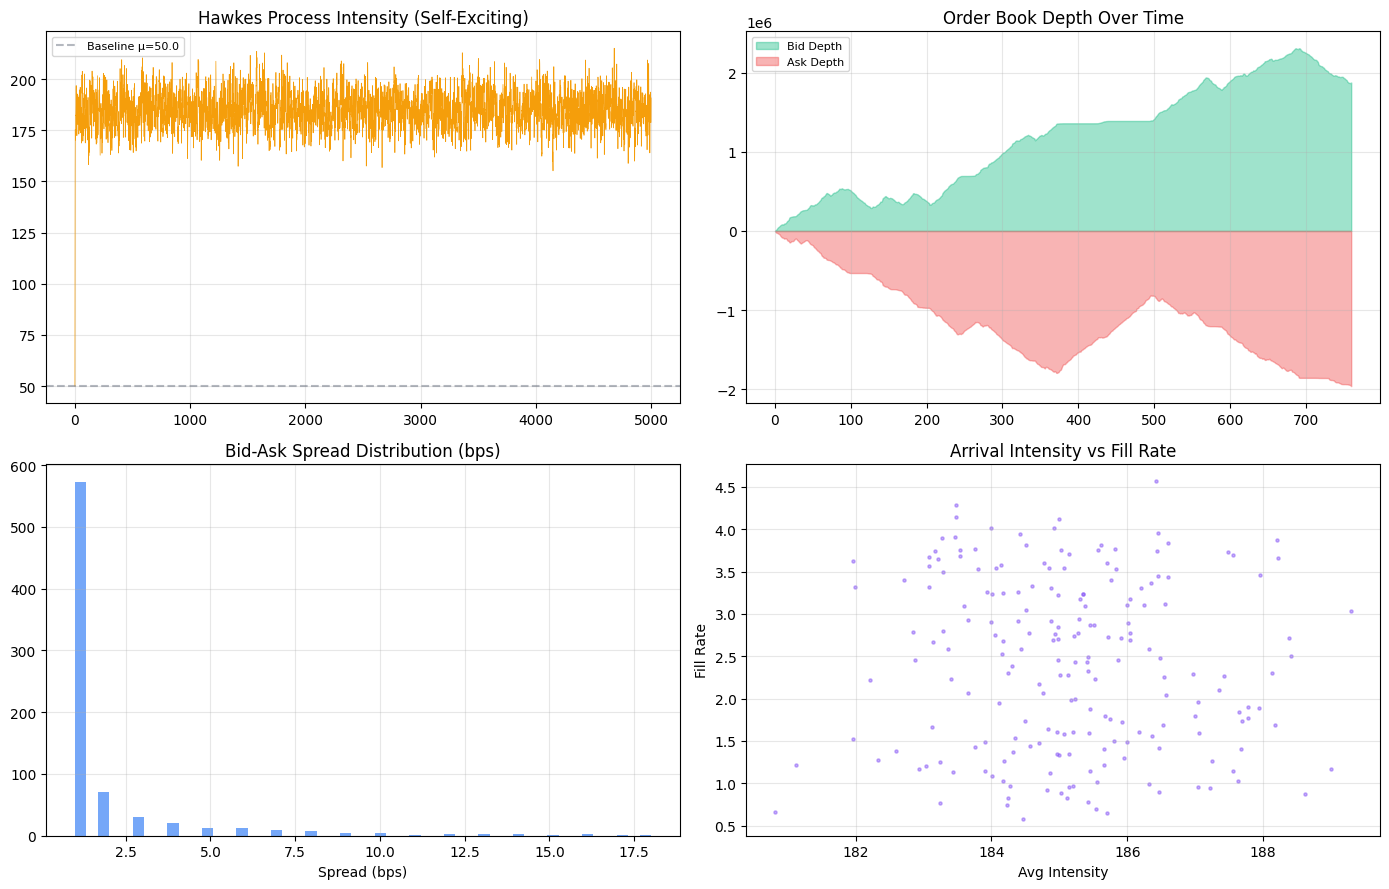

In [4]:
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Hawkes intensity
axes[0, 0].plot(intensity[:5000], linewidth=0.5, color="#f59e0b")
axes[0, 0].axhline(mu, color="#6b7280", linestyle="--", alpha=0.5, label=f"Baseline μ={mu}")
axes[0, 0].set_title("Hawkes Process Intensity (Self-Exciting)")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Depth evolution
if len(depth_df) > 0:
    axes[0, 1].fill_between(range(len(depth_df)), depth_df["bid_depth"],
                           alpha=0.4, color="#10b981", label="Bid Depth")
    axes[0, 1].fill_between(range(len(depth_df)), -depth_df["ask_depth"].values,
                           alpha=0.4, color="#ef4444", label="Ask Depth")
    axes[0, 1].set_title("Order Book Depth Over Time")
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].grid(True, alpha=0.3)

# Spread histogram
if len(depth_df) > 0:
    spreads = depth_df["spread"][depth_df["spread"] > 0] * 10000 / 100
    axes[1, 0].hist(spreads, bins=50, color="#3b82f6", alpha=0.7, edgecolor="none")
    axes[1, 0].set_title("Bid-Ask Spread Distribution (bps)")
    axes[1, 0].set_xlabel("Spread (bps)")
    axes[1, 0].grid(True, alpha=0.3)

# Arrival intensity vs fill rate (scatter)
chunk = 100
n_chunks = min(len(orders_df) // chunk, 200)
chunk_intensity = [intensity[i*chunk:(i+1)*chunk].mean() for i in range(n_chunks)]
chunk_fills = []
for i in range(n_chunks):
    chunk_trades = trades_df[(trades_df["tick"] >= i*chunk) & (trades_df["tick"] < (i+1)*chunk)]
    chunk_fills.append(len(chunk_trades) / chunk)
axes[1, 1].scatter(chunk_intensity, chunk_fills, s=5, alpha=0.5, color="#8b5cf6")
axes[1, 1].set_xlabel("Avg Intensity")
axes[1, 1].set_ylabel("Fill Rate")
axes[1, 1].set_title("Arrival Intensity vs Fill Rate")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
import json
from datetime import datetime

results_export = {
    "project_id": "engines_01_lob_simulator",
    "timestamp": datetime.now().isoformat(),
    "type": "engine_benchmark",
    "metrics": {},
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print("Results exported to results.json")


Results exported to results.json


## Summary

### Limit Order Book Simulator

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
